## Multiple Object Tracking

In [1]:
import sys
sys.path.append('../src')
import os
from pathlib import Path
os.chdir(Path(__file__).parent if "__file__" in dir() else Path().resolve())

from nuscenes.nuscenes import NuScenes
import numpy as np
import matplotlib.pyplot as plt
from multi_object_tracker import MultiObjectTracker

# Load nuScenes
nusc = NuScenes(version='v1.0-mini', dataroot=r'C:\Projects\SENTINEL\data\data_Nuscenes', verbose=False)

print("✅ nuScenes loaded")

# Get scene
my_scene = nusc.scene[0]
print(f"Scene: {my_scene['name']}")
print(f"Samples: {my_scene['nbr_samples']}")


✅ nuScenes loaded
Scene: scene-0061
Samples: 39


## Extracting all vehicles of all frames

In [2]:
def get_all_vehicles_in_sample(nusc, sample_token):
    """Extract all vehicle positions from a sample"""
    sample = nusc.get('sample', sample_token)
    vehicles = []
    
    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        
        if 'vehicle' in ann['category_name']:
            vehicles.append({
                'position': ann['translation'][:2],  # [x, y]
                'instance_token': ann['instance_token']
            })
    
    return vehicles

def extract_scene_detections(nusc, scene):
    """
    Extract all vehicle detections across entire scene
    
    Returns:
        List of frames, each containing list of detections
    """
    all_frames = []
    sample_token = scene['first_sample_token']
    
    while sample_token:
        sample = nusc.get('sample', sample_token)
        
        # Get vehicles in this frame
        vehicles = get_all_vehicles_in_sample(nusc, sample_token)
        detections = [v['position'] for v in vehicles]
        
        all_frames.append({
            'timestamp': sample['timestamp'] / 1e6,
            'detections': detections
        })
        
        sample_token = sample['next']
    
    return all_frames

# Extract detections
frames = extract_scene_detections(nusc, my_scene)

print(f"\n✅ Extracted {len(frames)} frames")
print(f"Example frame 0: {len(frames[0]['detections'])} vehicles")
print(f"Example frame 10: {len(frames[10]['detections'])} vehicles")



✅ Extracted 39 frames
Example frame 0: 13 vehicles
Example frame 10: 22 vehicles


## Running MOT

In [3]:
# Create tracker
tracker = MultiObjectTracker(
    max_age=5,       # Keep tracks for 5 frames without detection
    min_hits=3,      # Need 3 detections to confirm track
    max_distance=10.0,  # Max 10m for valid association
    dt=0.5           # ~0.5 seconds between samples
)

# Track through all frames
all_tracks = []

for frame_idx, frame in enumerate(frames):
    # Get confirmed tracks
    confirmed_tracks = tracker.update(frame['detections'])
    
    all_tracks.append({
        'frame': frame_idx,
        'timestamp': frame['timestamp'],
        'tracks': confirmed_tracks,
        'n_detections': len(frame['detections'])
    })
    
    if frame_idx % 10 == 0:
        print(f"Frame {frame_idx}: {len(frame['detections'])} detections, "
              f"{len(confirmed_tracks)} confirmed tracks")

print(f"\n✅ Tracking complete!")
print(f"Total frames processed: {len(all_tracks)}")


Frame 0: 13 detections, 0 confirmed tracks
Frame 10: 22 detections, 21 confirmed tracks
Frame 20: 21 detections, 21 confirmed tracks
Frame 30: 17 detections, 20 confirmed tracks

✅ Tracking complete!
Total frames processed: 39


## Visualizing Multiple Object Tracking

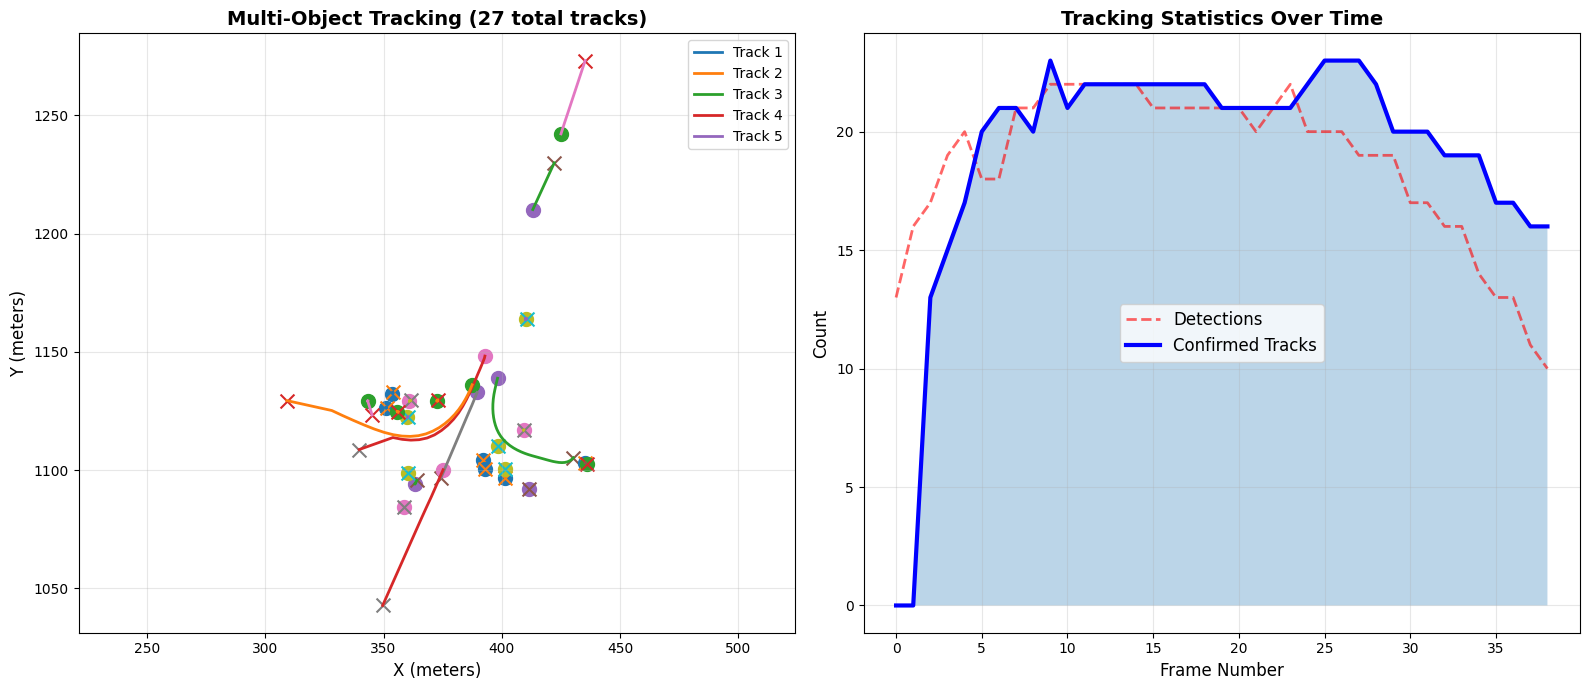


MULTI-OBJECT TRACKING RESULTS
Total unique tracks: 27
Average tracks per frame: 19.2
Max tracks in single frame: 23
Total frames processed: 39


In [4]:
# Plot tracking results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: All trajectories
track_positions = {}  # {track_id: [(x, y), ...]}

for frame_data in all_tracks:
    for track in frame_data['tracks']:
        track_id = track['id']
        position = track['position']
        
        if track_id not in track_positions:
            track_positions[track_id] = []
        
        track_positions[track_id].append(position)

# Draw each track with unique color
for track_id, positions in track_positions.items():
    if len(positions) > 5:  # Only show tracks with 5+ points
        positions = np.array(positions)
        
        # Get track color (consistent from tracker)
        ax1.plot(positions[:, 0], positions[:, 1], 
                linewidth=2, label=f'Track {track_id}' if track_id < 6 else '')
        ax1.scatter(positions[0, 0], positions[0, 1], s=100, marker='o')
        ax1.scatter(positions[-1, 0], positions[-1, 1], s=100, marker='x')

ax1.set_xlabel('X (meters)', fontsize=12)
ax1.set_ylabel('Y (meters)', fontsize=12)
ax1.set_title(f'Multi-Object Tracking ({len(track_positions)} total tracks)', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot 2: Track count over time
frame_numbers = [f['frame'] for f in all_tracks]
n_tracks = [len(f['tracks']) for f in all_tracks]
n_detections = [f['n_detections'] for f in all_tracks]

ax2.plot(frame_numbers, n_detections, 'r--', linewidth=2, label='Detections', alpha=0.6)
ax2.plot(frame_numbers, n_tracks, 'b-', linewidth=3, label='Confirmed Tracks')
ax2.fill_between(frame_numbers, n_tracks, alpha=0.3)

ax2.set_xlabel('Frame Number', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Tracking Statistics Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("MULTI-OBJECT TRACKING RESULTS")
print("="*60)
print(f"Total unique tracks: {len(track_positions)}")
print(f"Average tracks per frame: {np.mean(n_tracks):.1f}")
print(f"Max tracks in single frame: {np.max(n_tracks)}")
print(f"Total frames processed: {len(all_tracks)}")
print("="*60)
